✓ Animation saved: day27_animation.mp4
✓ Individual frames saved: day27_frame_*.png


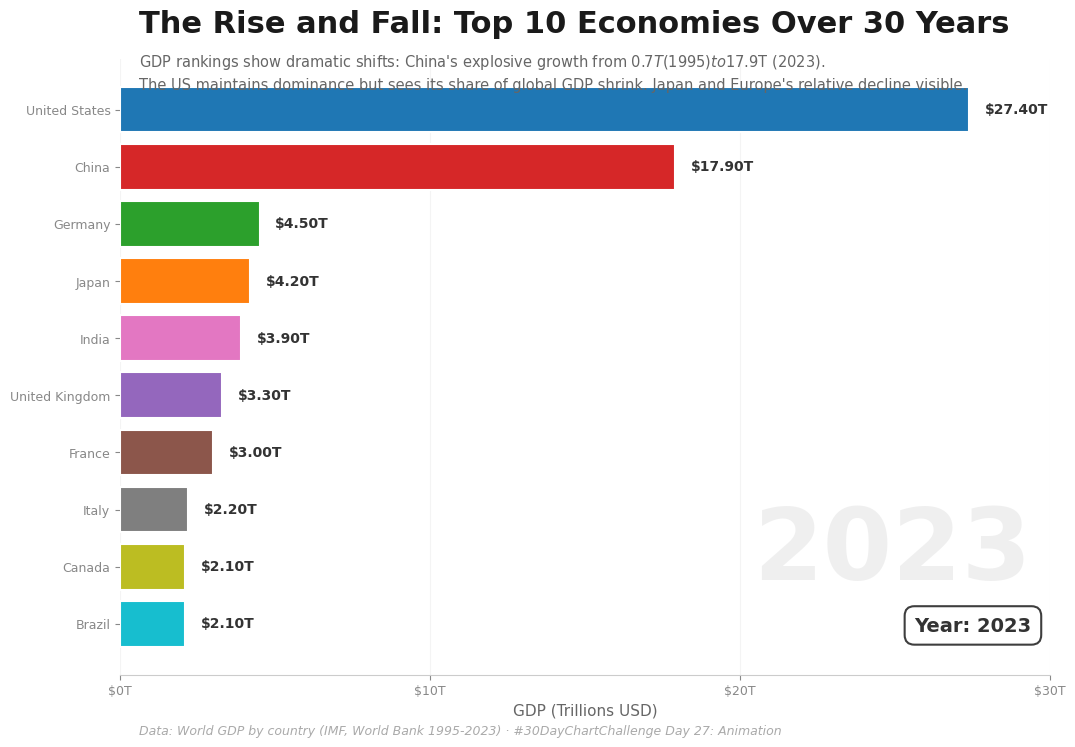

In [1]:
"""
#30DayChartChallenge — Day 27: Animation
"The Rise and Fall: Top 10 Economies Over 30 Years" — animated bar chart race
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: GDP rankings by country (1995-2023)
Creates an animated visualization showing changes over time.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Top 10 economies over time (GDP in Trillions USD)
# ---------------------------------------------------------------------------
data = {
    "Year": [1995, 2000, 2005, 2010, 2015, 2018, 2020, 2023],
    "United States": [7.6, 10.2, 13.1, 15.0, 18.2, 20.5, 20.9, 27.4],
    "China": [0.7, 1.2, 2.3, 6.1, 11.1, 14.3, 14.9, 17.9],
    "Japan": [5.3, 5.0, 4.9, 5.9, 4.4, 5.1, 5.1, 4.2],
    "Germany": [2.8, 3.8, 4.1, 3.9, 3.9, 4.1, 3.8, 4.5],
    "United Kingdom": [1.8, 2.4, 2.9, 2.4, 2.9, 2.8, 2.9, 3.3],
    "France": [1.8, 2.3, 2.7, 2.7, 2.4, 2.8, 2.7, 3.0],
    "India": [0.3, 0.5, 0.8, 1.7, 2.2, 2.7, 2.9, 3.9],
    "Italy": [1.2, 1.2, 1.9, 2.0, 1.8, 2.0, 2.0, 2.2],
    "Canada": [0.6, 0.7, 1.0, 1.6, 1.6, 1.7, 1.7, 2.1],
    "Brazil": [0.7, 0.8, 0.9, 2.2, 1.8, 1.9, 1.8, 2.1],
}

df = pd.DataFrame(data)

# ---------------------------------------------------------------------------
# 2. ANIMATION SETUP
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Colors for countries
colors_map = {
    "United States": "#1f77b4",
    "China": "#d62728",
    "Japan": "#ff7f0e",
    "Germany": "#2ca02c",
    "United Kingdom": "#9467bd",
    "France": "#8c564b",
    "India": "#e377c2",
    "Italy": "#7f7f7f",
    "Canada": "#bcbd22",
    "Brazil": "#17becf"
}

def animate(frame):
    ax.clear()
    ax.set_facecolor("#FFFFFF")
    
    # Get data for current year
    year_idx = frame
    year = df["Year"].iloc[year_idx]
    
    # Sort countries by GDP for this year
    year_data = df.iloc[year_idx, 1:].sort_values(ascending=True).tail(10)
    
    # Create bar chart
    bars = ax.barh(range(len(year_data)), year_data.values, 
                   color=[colors_map[country] for country in year_data.index],
                   edgecolor="white", linewidth=1.5, zorder=3)
    
    # Y-axis labels
    ax.set_yticks(range(len(year_data)))
    ax.set_yticklabels(year_data.index, fontsize=11, fontweight="500", color="#333333")
    
    # Add value labels
    for i, (country, value) in enumerate(year_data.items()):
        ax.text(value + 0.5, i, f"${value:.2f}T", 
                fontsize=10, fontweight="600", color="#333333", va="center")
    
    # Minimal styling
    ax.set_xlim(0, 30)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.xaxis.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xticks([0, 10, 20, 30])
    ax.set_xticklabels(["$0T", "$10T", "$20T", "$30T"], fontsize=9, color="#888888")
    ax.tick_params(colors="#888888", labelsize=9)
    
    # Title with dynamic year
    ax.text(0.02, 1.08, "The Rise and Fall: Top 10 Economies Over 30 Years",
            fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")
    
    ax.text(0.02, 1.01,
            "GDP rankings show dramatic shifts: China's explosive growth from $0.7T (1995) to $17.9T (2023).\n"
            "The US maintains dominance but sees its share of global GDP shrink. Japan and Europe's relative decline visible.",
            fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)
    
    # Year label (large, dynamic)
    ax.text(0.98, 0.20, str(int(year)),
            fontsize=72, fontweight="bold", color="#cccccc", transform=ax.transAxes,
            ha="right", va="center", alpha=0.3, zorder=1)
    
    ax.text(0.98, 0.08, f"Year: {int(year)}",
            fontsize=14, fontweight="bold", color="#333333", transform=ax.transAxes, 
            ha="right", va="center",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff", edgecolor="#333333", linewidth=1.5, alpha=0.95))
    
    # Source
    ax.text(0.02, -0.08,
            "Data: World GDP by country (IMF, World Bank 1995-2023) · #30DayChartChallenge Day 27: Animation",
            fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="top")
    
    ax.set_xlabel("GDP (Trillions USD)", fontsize=11, color="#666666", fontweight="500")

# Create animation
frames = len(df)
anim = animation.FuncAnimation(fig, animate, frames=frames, interval=600, repeat=True, repeat_delay=1000)

# Save animation
anim.save("day27_animation.mp4", writer="ffmpeg", fps=1.5, dpi=150)
print("✓ Animation saved: day27_animation.mp4")

# Also save individual frames as PNG for viewing
for i in range(len(df)):
    animate(i)
    plt.savefig(f"day27_frame_{i:02d}.png", dpi=150, facecolor="#FFFFFF", bbox_inches="tight")

print("✓ Individual frames saved: day27_frame_*.png")
plt.show()